In [1]:
import gmsh
import ufl
import pyvista as pv
import numpy as np
import dolfinx.io as dio
import adios4dolfinx

from scipy.spatial import KDTree
from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, plot, mesh
from dolfinx.fem import Constant, Function
from dolfinx.fem.petsc import LinearProblem, assemble_vector
from basix.ufl import element, mixed_element
from petsc4py import PETSc


In [2]:
def map_facet_tags_from_msh_to_bp(meshfile: Path, bpfile: Path, tol: float = 1e-10):
    """
    Map facet tags from a .msh file onto the mesh read from a .bp file.
    Returns
    -------
    domain : dolfinx.Mesh
        The mesh read from the .bp file.
    facet_tags_bp : dolfinx.MeshTags
        Facet tags mapped onto the BP mesh.
    """
    # --- Load both meshes ---
    mesh_msh, _, facet_tags_msh = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
    mesh_msh.topology.create_connectivity(mesh_msh.topology.dim - 1, mesh_msh.topology.dim)

    domain = adios4dolfinx.read_mesh(bpfile, MPI.COMM_WORLD)
    domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)
    tdim = domain.topology.dim

    # --- Compute facet centroids ---
    def facet_centroids(m):
        f2v = m.topology.connectivity(tdim - 1, 0)
        X = m.geometry.x
        nF = m.topology.index_map(tdim - 1).size_local
        C = np.zeros((nF, X.shape[1]))
        for f in range(nF):
            C[f] = X[f2v.links(f)].mean(axis=0)
        return C

    cent_msh = facet_centroids(mesh_msh)
    cent_bp = facet_centroids(domain)

    # --- Match via KDTree ---
    tree = KDTree(cent_bp)
    bp_ids, bp_vals = [], []
    for f_msh, val in zip(facet_tags_msh.indices, facet_tags_msh.values):
        dist, f_bp = tree.query(cent_msh[f_msh])
        if dist < tol:
            bp_ids.append(f_bp)
            bp_vals.append(val)

    facet_tags_bp = mesh.meshtags(domain, tdim - 1,
                                   np.array(bp_ids, np.int32),
                                   np.array(bp_vals, np.int32))

    if MPI.COMM_WORLD.rank == 0:
        print(f"✅ facet tags mapped .msh → .bp | unique values: {np.unique(facet_tags_bp.values)}")

    return domain, facet_tags_bp

In [3]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()
wind_file = Path("../wind_data/airflow_picard.bp").resolve()

domain, facet_tags = map_facet_tags_from_msh_to_bp(meshfile, wind_file)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])

W = fem.functionspace(domain, mixed_elem)
W0, W1 = W.sub(0), W.sub(1)
V, V_to_W = W0.collapse() 
Q, Q_to_W = W1.collapse()

nu = fem.Constant(domain, PETSc.ScalarType(1.5e-4))

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
✅ facet tags mapped .msh → .bp | unique values: [2 3 4 5 6 7 8 9]
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


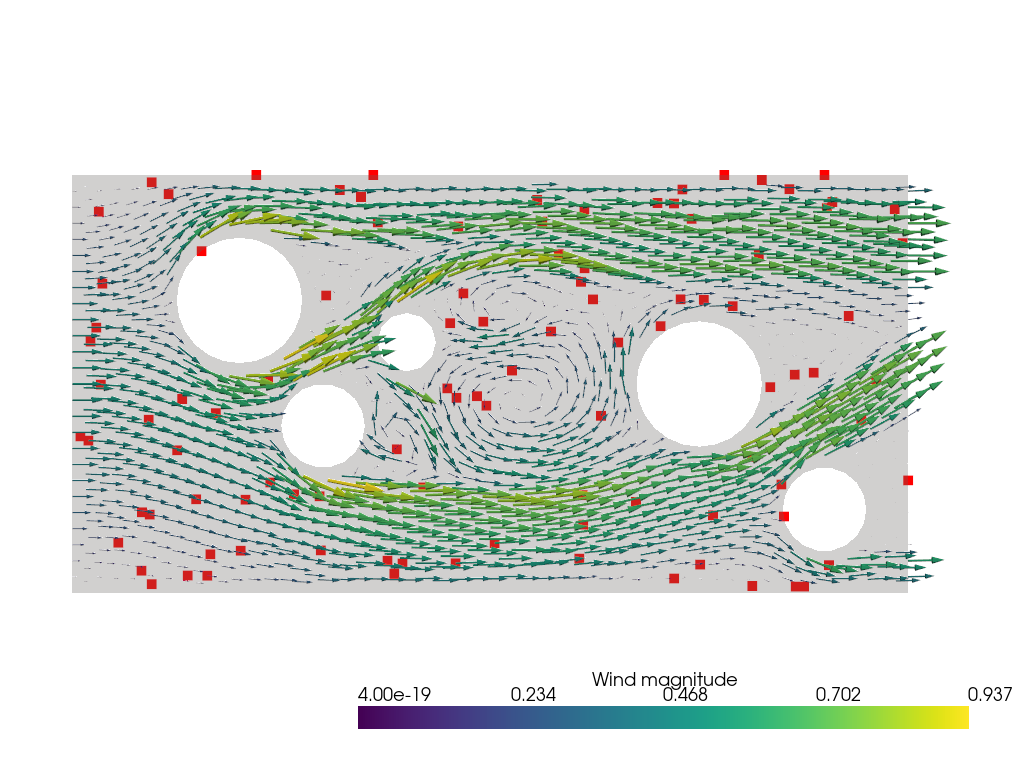

In [4]:
# Load true velocity fields in P2 and P1
u_true = fem.Function(V)
adios4dolfinx.read_function(wind_file, u_true, name="velocity_H2")

# Random P2 samples
coords_P2 = V.tabulate_dof_coordinates()
p = 100
rng = np.random.default_rng(1)
sample_ids = rng.choice(len(coords_P2), size=p, replace=False)

x_ids = sample_ids * 2
y_ids = sample_ids * 2 + 1
measurement_ids = np.stack((x_ids, y_ids)).T.flatten()

measured_fun = fem.Function(V)
measured_fun.x.array[:] = 0.0
measured_fun.x.array[measurement_ids] = u_true.x.array[measurement_ids]

# --- Prepare visualization of wind field and sampled points ---
sample_points_2d = coords_P2[sample_ids, :2]
sample_points_3d = np.column_stack((sample_points_2d, np.zeros(p)))

# Additional P1 space for wind visualization
V_vis = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1, shape=(2,))) 
u_true_vis = fem.Function(V_vis)
adios4dolfinx.read_function(wind_file, u_true_vis, name="velocity_H1")

topology, cell_type, geom = plot.vtk_mesh(domain)
grid = pv.UnstructuredGrid(topology, cell_type, geom)

wind2d = u_true_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.15)

measured = pv.PolyData(sample_points_3d)

# --- Plot ---
pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind magnitude"})
pl.add_mesh(measured, color="red", point_size=10, label="Sample DOFs (P2)")
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

In [5]:
# No slip boundary conditions on obstacles and walls
u_D_no_slip = fem.Function(V)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs, W0)

def visualize_mixed(mixed_function: fem.Function, scale=1.0):
    u_c = mixed_function.sub(0).collapse()
    p_c = mixed_function.sub(1).collapse()

    u_grid = pv.UnstructuredGrid(*plot.vtk_mesh(u_c.function_space))

    # Pad u to be 3D
    gdim = u_c.function_space.mesh.geometry.dim
    assert len(u_c) == gdim
    u_values = np.zeros((len(u_c.x.array) // gdim, 3), dtype=np.float64)
    u_values[:, :gdim] = u_c.x.array.real.reshape((-1, gdim))

    # Create a point cloud of glyphs
    u_grid["u"] = u_values
    glyphs = u_grid.glyph(orient="u", factor=scale)
    plotter = pv.Plotter()
    plotter.add_mesh(u_grid, show_edges=False, show_scalar_bar=False)
    plotter.add_mesh(glyphs)
    plotter.view_xy()
    plotter.show()

    p_grid = pv.UnstructuredGrid(*plot.vtk_mesh(p_c.function_space))
    p_grid.point_data["p"] = p_c.x.array
    plotter_p = pv.Plotter()
    plotter_p.add_mesh(p_grid, show_edges=False)
    plotter_p.view_xy()
    plotter_p.show()

# Outflow - zero pressure
p_zero = fem.Function(Q)
p_zero.x.array[:] = 0.0
dofs_local = facet_tags.find(name_to_id["Outflow"])
dofs_out = fem.locate_dofs_topological((W1, Q), V.mesh.topology.dim - 1, dofs_local)

bc_out = fem.dirichletbc(p_zero, dofs_out, W1)

#Inflow boundary condition (unknown, set first guess)
u_inflow = fem.Function(V)
u_inflow.interpolate(lambda x: (1.0 * np.ones_like(x[0]), 0.0 * np.ones_like(x[0])))
inflow_facets = facet_tags.find(name_to_id["Inflow"])
inflow_dofs_W0 = fem.locate_dofs_topological((W0, V), domain.topology.dim - 1, inflow_facets)
inflow_dofs_V = inflow_dofs_W0[1]

bc_inflow = fem.dirichletbc(u_inflow, inflow_dofs_W0, W0)

ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
ds_inflow = ds(name_to_id["Inflow"])

In [6]:
# Functions needed for adjoint algorithm

def misfit_val(u, measured_fun, mask_fun):
    diff = u - measured_fun
    J = 0.5 * fem.assemble_scalar(fem.form(ufl.inner(diff, diff) * mask_fun * ufl.dx))
    return J

def solve_forward(W: fem.FunctionSpace, bcs: list, 
                  nu_value: float | None = 1.5e-4, 
                  max_picard: int | None = 20, 
                  tol_picard: float | None = 1e-8, 
                  omega: float | None = 0.5,
                  initial_wh: fem.Function | None = None):

    domain = W.mesh

    (u, p) = ufl.TrialFunctions(W)
    (v, q) = ufl.TestFunctions(W)
    
    wh = fem.Function(W)
    wh_prev = fem.Function(W)
    uh_prev, _ = ufl.split(wh_prev)

    if initial_wh is not None:
        wh_prev.x.array[:] = initial_wh.x.array
    
    else:
        wh_prev.x.array[:] = 0.0

    nu = fem.Constant(domain, PETSc.ScalarType(nu_value))

    h = ufl.CellDiameter(domain)
    abs_u_prev = ufl.sqrt(ufl.dot(uh_prev, uh_prev)) + 1e-12
    tau = 1.0 / ((2.0 * abs_u_prev) / h + 4.0 * nu / (h*h) + 1e-8)

    a_nav_stokes = (
        nu * ufl.inner(ufl.nabla_grad(u), ufl.nabla_grad(v))
        + ufl.inner(ufl.dot(uh_prev, ufl.nabla_grad(u)), v)
        - ufl.inner(p, ufl.div(v))
        + ufl.inner(ufl.div(u), q)
    ) * ufl.dx

    Rm_trial = (
        ufl.dot(uh_prev, ufl.nabla_grad(u)) - nu * ufl.div(ufl.nabla_grad(u)) + ufl.nabla_grad(p)
    )
    supg = tau * ufl.inner(ufl.dot(uh_prev, ufl.nabla_grad(v)), Rm_trial) * ufl.dx

    a_picard = a_nav_stokes + supg
    L_picard = ufl.inner(fem.Constant(domain, PETSc.ScalarType((0.0, 0.0))), v) * ufl.dx

    for k in range(max_picard):
        prob = LinearProblem(
            a_picard, L_picard, bcs, wh,
            petsc_options={"ksp_type":"gmres","pc_type":"lu","ksp_rtol":1e-8,"ksp_max_it":20}
        )
        prob.solve()

        # Dämpfung
        wh.x.array[:] = (1 - omega) * wh_prev.x.array + omega * wh.x.array

        # Konvergenzmaß
        diff_u = wh.sub(0) - wh_prev.sub(0)
        l2_step_sq = fem.assemble_scalar(fem.form(ufl.inner(diff_u, diff_u) * ufl.dx))
        l2_step = float(np.sqrt(max(l2_step_sq, 0.0)))
        norm_new_sq = fem.assemble_scalar(fem.form(ufl.inner(wh.sub(0), wh.sub(0)) * ufl.dx))
        rel_step = l2_step / (np.sqrt(max(norm_new_sq, 1e-30)) + 1e-12)
        # print(f"Iter {k}: Rel L2 step = {rel_step:.3e}")

        if rel_step < tol_picard:
            break

        wh_prev.x.array[:] = wh.x.array[:]

    return wh

def solve_adjoint(W: fem.FunctionSpace, bcs: list, fwd_sol: fem.Function , 
                  source_fun: fem.Function, nu_value: float | None = 1.5e-4):
    """
        -nu Δλ - (u_fwd·∇)λ + (∇u_fwd)^T λ + ∇μ = source_fun
        div(λ) = 0
    """
    domain = W.mesh
    (lam, mu) = ufl.TrialFunctions(W)
    (v, q) = ufl.TestFunctions(W)

    wh = fem.Function(W)
    nu = fem.Constant(domain, PETSc.ScalarType(nu_value))

    u_fwd = fwd_sol.sub(0).collapse()

    # SUPG
    h = ufl.CellDiameter(domain)
    abs_u = ufl.sqrt(ufl.dot(u_fwd, u_fwd)) + 1e-12
    tau = 1.0 / ((2.0 * abs_u) / h + 4.0 * nu / (h * h) + 1e-8)

    # --- Adjoint weak form ---
    a_adj = (
        nu * ufl.inner(ufl.grad(lam), ufl.grad(v))
        #- ufl.inner(ufl.dot(u_fwd, ufl.grad(lam)), v)
        - ufl.inner(ufl.dot(ufl.grad(lam), u_fwd), v)
        + ufl.inner(ufl.dot(ufl.grad(u_fwd).T, lam), v)
        - ufl.inner(mu, ufl.div(v))
        + ufl.inner(ufl.div(lam), q)
    ) * ufl.dx

    # --- SUPG-Stabilisierung (optional)
    Rm = (
        - ufl.dot(u_fwd, ufl.grad(lam))
        + ufl.dot(ufl.grad(u_fwd).T, lam)
        - nu * ufl.div(ufl.grad(lam))
        + ufl.grad(mu)
    )
    supg = - tau * ufl.inner(ufl.dot(u_fwd, ufl.grad(v)), Rm) * ufl.dx

    a_adj += supg

    # --- Rechte Seite ---
    L_adj = ufl.inner(source_fun, v) * ufl.dx

    # --- Solve linear system ---
    prob = LinearProblem(
        a_adj, L_adj, bcs, u=wh,
        petsc_options={
            "ksp_type": "gmres",
            "pc_type": "lu",
            "ksp_rtol": 1e-8,
            "ksp_max_it": 20,
            #"ksp_monitor": None,
        },
    )
    prob.solve()

    return wh

def compute_boundary_gradient(u_bdry: fem.Function, sol_adj: fem.Function, 
                      ds_in: ufl.Measure, gamma: float, nu: fem.Constant) -> np.ndarray:

    Vh = u_bdry.function_space
    mesh = Vh.mesh
    n = ufl.FacetNormal(mesh)

    # λ, μ = adjoint velocity and pressure
    lam, mu = sol_adj.sub(0), sol_adj.sub(1)

    # Adjoint stress tensor: S_adj = ν(∇λ + ∇λᵀ) − μI
    S_adj = nu * (ufl.grad(lam) + ufl.grad(lam).T) - mu * ufl.Identity(mesh.topology.dim)

    # Boundary gradient expression: g = S_adj · n
    g_expr = ufl.dot(S_adj, n)

    # L² projection on Γ_in:  (M g, v)_Γ = (g_expr, v)_Γ + γ (m, v)_Γ
    uh, vh = ufl.TrialFunction(Vh), ufl.TestFunction(Vh)

    # Boundary mass matrix  M_ij = ∫_Γ_in φ_i · φ_j ds
    Mb = fem.form(ufl.inner(uh, vh) * ds_in)
    Afull = fem.petsc.assemble_matrix(Mb)
    Afull.assemble()

    # RHS from adjoint stress: b_i = ∫_Γ_in g_expr · φ_i ds
    bb = fem.form(ufl.inner(g_expr, vh) * ds_in)
    bfull = fem.petsc.assemble_vector(bb)

    # Regularization term: add γ M m
    m_vec = PETSc.Vec().createWithArray(u_bdry.x.array, comm=PETSc.COMM_SELF)
    tmp = Afull.createVecRight()
    Afull.mult(m_vec, tmp)
    bfull.axpy(gamma, tmp)

    # Restrict to inflow DOFs: M_in g_in = b_in
    is_in = PETSc.IS().createGeneral(inflow_dofs_V.astype(np.int32))
    A = Afull.createSubMatrix(is_in, is_in)
    b = bfull.getSubVector(is_in)

    # Solve L²-projection system on Γ_in
    ksp = PETSc.KSP().create(comm=PETSc.COMM_SELF)
    ksp.setOperators(A)
    ksp.setType("cg")
    ksp.getPC().setType("icc")
    ksp.setTolerances(rtol=1e-12)
    x_in = b.duplicate()
    ksp.solve(b, x_in)

    # Boundary gradient back into global vector
    gradJ = np.zeros_like(u_bdry.x.array)
    gradJ[inflow_dofs_V] = x_in.getArray()

    # # Debug info
    # g_stress = S_adj @ n
    # g_reg = gamma * u_inflow
    # print("‣ stress term avg:", np.mean(np.abs(g_stress.x.array)))
    # print("‣ reg term avg:", np.mean(np.abs(g_reg.x.array)))

    return gradJ

In [7]:
# Sub matrix on inflow dofs
uh, vh = ufl.TrialFunction(V), ufl.TestFunction(V)
A_bdry_form = fem.form(ufl.inner(uh, vh) * ds_inflow)
A_bdry = fem.petsc.assemble_matrix(A_bdry_form)
A_bdry.assemble()

# Restrict to inflow boundary DOFs only
is_in = PETSc.IS().createGeneral(inflow_dofs_V.astype(np.int32))
M_in = A_bdry.createSubMatrix(is_in, is_in)

In [8]:
w = fem.Function(W)
w.x.array[:] = 0.0
w_old = fem.Function(W)
w_old.x.array[:] = 0.0

# --- Mask function for adjoint source ---
V_scalar = fem.functionspace(domain, ("Lagrange", 2))
sample_mask_fun = fem.Function(V_scalar)
sample_mask_fun.x.array[:] = 0.0
sample_mask_fun.x.array[sample_ids] = 1.0

pl = pv.Plotter()


In [9]:
# --- Optimization parameters ---
max_it = 200
gamma = 1e-3
alpha0 = 1.0
tol_rel = 1e-7
tol_grad = 1e-8
c_arm = 1e-5
rho = 0.5
alpha_hist = []
misfit_hist = []

sol_fwd = fem.Function(W)
sol_fwd.x.array[:] = 0.0

for it in range(10):
    # --- Dirichlet BC on inflow ---
    bc_inflow = fem.dirichletbc(u_inflow, inflow_dofs_W0, W0)
    bc_inflow.set(sol_fwd.x.array)
    sol_fwd.x.scatter_forward()

    # --- Forward solve ---
    sol_fwd = solve_forward(W, [bc_no_slip, bc_out, bc_inflow], max_picard=10, initial_wh=sol_fwd)
    u, p = sol_fwd.sub(0).collapse(), sol_fwd.sub(1).collapse()
    u_norm = np.linalg.norm(u.x.array)
    print(f"\nIteration {it}")
    print(f"‣ L2 norm of velocity: {u_norm:.6e}")

    # --- Misfit ---
    mis = misfit_val(u, measured_fun, sample_mask_fun)

    # --- Adjoint solve ---
    adj_rhs = sample_mask_fun * (u - measured_fun)
    sol_adj = solve_adjoint(W, [bc_no_slip, bc_out], sol_fwd, adj_rhs)
    lam, mu = sol_adj.sub(0).collapse(), sol_adj.sub(1).collapse()

    # --- Gradient on inflow DOFs (x & y together) ---
    gradJ = compute_boundary_gradient(u_inflow, sol_adj, ds_inflow, gamma, nu)
    
    g_in = PETSc.Vec().createWithArray(gradJ[inflow_dofs_V], comm=PETSc.COMM_SELF)
    Mg  = M_in.createVecRight(); M_in.mult(g_in, Mg)
    dirderiv = - g_in.dot(Mg)

    # # wrong grad norm 
    # grad_norm = np.linalg.norm(gradJ[inflow_dofs_V])
    # print(f"‣ grad_norm: {grad_norm:.3e}")

    alpha = alpha0
    inflow_trial = fem.Function(V)

    while True:
        inflow_trial.x.array[:] = u_inflow.x.array
        inflow_trial.x.array[inflow_dofs_V] -= alpha * gradJ[inflow_dofs_V]
        inflow_trial.x.scatter_forward()

        bc_inflow_trial = fem.dirichletbc(inflow_trial, inflow_dofs_W0, W0)
        sol_trial = solve_forward(W, [bc_no_slip, bc_out, bc_inflow_trial],
                                max_picard=10, initial_wh=sol_fwd)  # s. Punkt 2
        u_trial = sol_trial.sub(0).collapse()
        mis_trial = misfit_val(u_trial, measured_fun, sample_mask_fun)

        if mis_trial <= mis + c_arm * alpha * dirderiv:
            break
        alpha *= rho
        if alpha < 1e-12:
            print("Alpha too small, breaking line search.")
            break
    u_inflow.x.array[inflow_dofs_V] -= alpha * gradJ[inflow_dofs_V]
    u_inflow.x.scatter_forward()

    bc_inflow = fem.dirichletbc(u_inflow, inflow_dofs_W0, W0)

    # --- Store progress ---
    misfit_hist.append(mis)
    alpha_hist.append(alpha)

    print(f"‣ α = {alpha:.2e}")
    print(f"‣ misfit = {mis:.3e}")

    # --- Convergence check ---
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or np.abs(dirderiv) < tol_grad:
            print(f"Converged at iteration {it+1}")
            break


Iteration 0
‣ L2 norm of velocity: 1.038591e+02
Alpha too small, breaking line search.
‣ α = 9.09e-13
‣ misfit = 3.291e-02

Iteration 1
‣ L2 norm of velocity: 1.057850e+02
Alpha too small, breaking line search.
‣ α = 9.09e-13
‣ misfit = 3.471e-02

Iteration 2
‣ L2 norm of velocity: 1.066729e+02
‣ α = 1.00e+00
‣ misfit = 3.529e-02

Iteration 3
‣ L2 norm of velocity: 1.051807e+02
‣ α = 1.00e+00
‣ misfit = 3.321e-02

Iteration 4
‣ L2 norm of velocity: 1.035383e+02
‣ α = 5.00e-01
‣ misfit = 3.008e-02

Iteration 5
‣ L2 norm of velocity: 1.035491e+02
Alpha too small, breaking line search.
‣ α = 9.09e-13
‣ misfit = 2.955e-02

Iteration 6
‣ L2 norm of velocity: 1.038482e+02
Alpha too small, breaking line search.
‣ α = 9.09e-13
‣ misfit = 3.190e-02

Iteration 7
‣ L2 norm of velocity: 1.036799e+02
‣ α = 5.00e-01
‣ misfit = 3.253e-02

Iteration 8
‣ L2 norm of velocity: 1.048547e+02
‣ α = 6.25e-02
‣ misfit = 3.236e-02

Iteration 9
‣ L2 norm of velocity: 1.067672e+02
‣ α = 2.50e-01
‣ misfit = 3.23

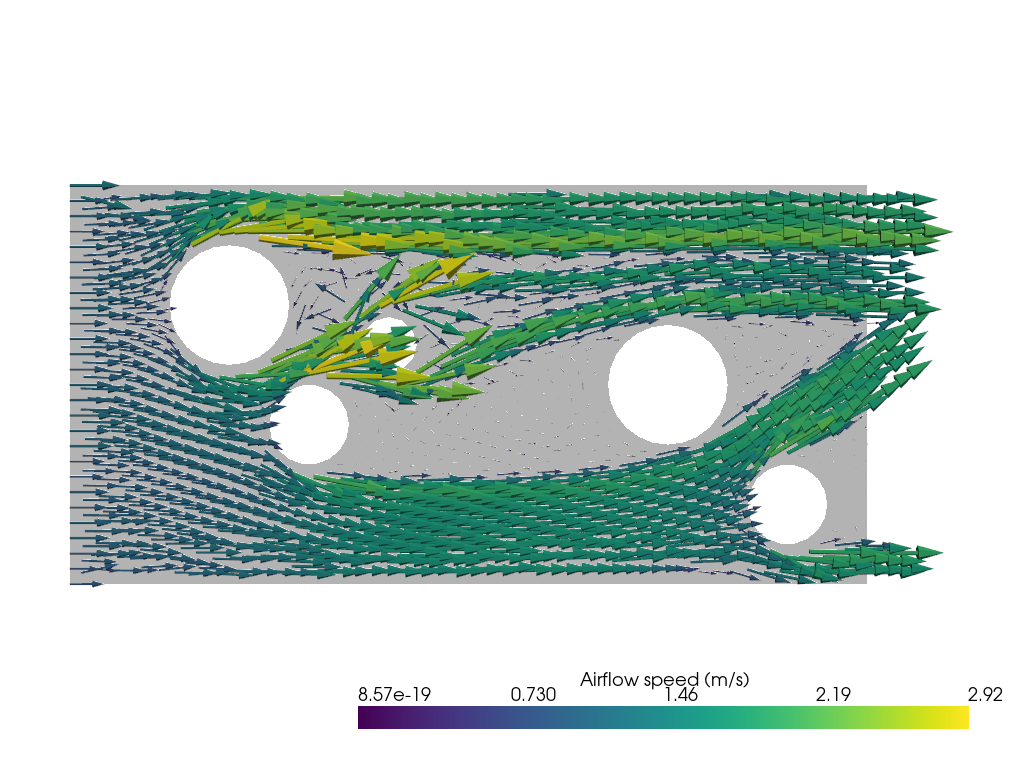

In [10]:
# Visualization
topology, cell_type, geom = plot.vtk_mesh(domain) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

V_u_vis = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1, shape=(domain.topology.dim,)))
u_vis = Function(V_u_vis)

u_vis.interpolate(u_trial)
wind2d = u_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
glyphs = grid.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

pl = pv.Plotter(off_screen=True)
pl.add_mesh(glyphs, scalar_bar_args={"title": f"Airflow speed (m/s)"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

In [11]:
u_inflow.x.array

array([ 1.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
       -1.50011774e-03,  1.02450846e+00,  8.33275210e-04], shape=(12280,))